## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

## Step 2: Load Dataset

In [2]:
df = pd.read_csv("Position_Salaries.csv")
print("Dataset:")
print(df.head())

Dataset:
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


## Step 3: Check for Categorical Variables and Apply One-Hot Encoding

In [3]:
categorical = input("Does the dataset contain categorical variables? (yes/no): ").lower()

if categorical == "yes":
    df = pd.get_dummies(df, drop_first=True)
    print("\nDataset after One-Hot Encoding:")
    print(df.head())

Does the dataset contain categorical variables? (yes/no):  yes



Dataset after One-Hot Encoding:
   Level  Salary  Position_C-level  Position_CEO  Position_Country Manager  \
0      1   45000             False         False                     False   
1      2   50000             False         False                     False   
2      3   60000             False         False                     False   
3      4   80000             False         False                     False   
4      5  110000             False         False                      True   

   Position_Junior Consultant  Position_Manager  Position_Partner  \
0                       False             False             False   
1                        True             False             False   
2                       False             False             False   
3                       False              True             False   
4                       False             False             False   

   Position_Region Manager  Position_Senior Consultant  \
0                    Fals

## Step 4: Get Target and Feature Columns from User

In [20]:
target_column = input("Enter the target column name: ")

feature_columns = input(
    "Enter feature column name(s) separated by commas: "
).split(",")


Enter the target column name:  Salary
Enter feature column name(s) separated by commas:  Level


## Step 5: Separate Features (X) and Target (y)

In [8]:
X = df[feature_columns]
y = df[target_column]

print("\nFeatures (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())


Features (X):
   Level
0      1
1      2
2      3
3      4
4      5

Target (y):
0     45000
1     50000
2     60000
3     80000
4    110000
Name: Salary, dtype: int64


## Step 6: Split Dataset into Training and Testing Sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Set Size:", len(X_train))
print("Testing Set Size:", len(X_test))


Training Set Size: 8
Testing Set Size: 2


## Step 7: Get Optional Hyperparameters from User

In [11]:
max_depth = input("Enter max_depth (press Enter for default): ")
min_samples_split = input("Enter min_samples_split (press Enter for default): ")
min_samples_leaf = input("Enter min_samples_leaf (press Enter for default): ")

max_depth = int(max_depth) if max_depth else None
min_samples_split = int(min_samples_split) if min_samples_split else 2
min_samples_leaf = int(min_samples_leaf) if min_samples_leaf else 1

Enter max_depth (press Enter for default):  
Enter min_samples_split (press Enter for default):  
Enter min_samples_leaf (press Enter for default):  


## Step 8: Create and Train Decision Tree Regressor

In [14]:
model = DecisionTreeRegressor(
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=42
)

model.fit(X_train, y_train)

print("\nDecision Tree Regression Model Trained Successfully!")


Decision Tree Regression Model Trained Successfully!


## Step 9: Make Predictions

In [17]:
y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)


Actual Values:
[500000  50000]

Predicted Values:
[300000.  45000.]


## Step 10: Evaluate Model using R² Score

In [18]:
r2 = r2_score(y_test, y_pred)
print("\nR² Score:", r2)


R² Score: 0.6046913580246913


## Step 11: Plot Graph (Only if Dataset Has One Feature)

C:\Users\Acer User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


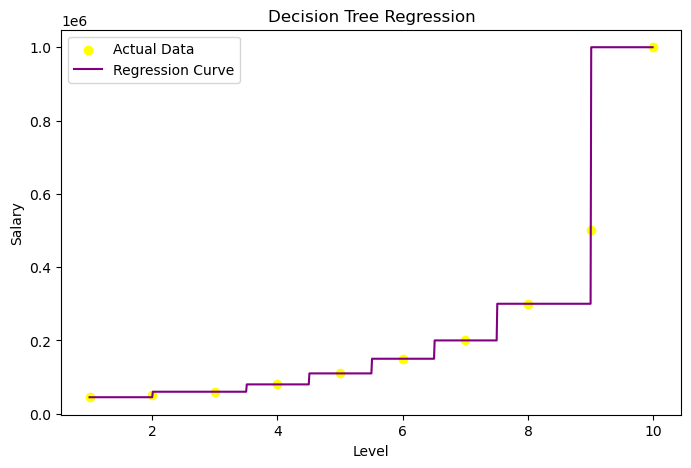

In [28]:
if X.shape[1] == 1:

    X_grid = np.arange(
        X.iloc[:, 0].min(),
        X.iloc[:, 0].max(),
        0.01
    )

    X_grid = X_grid.reshape((len(X_grid), 1))

    plt.figure(figsize=(8, 5))

    plt.scatter(
        X.iloc[:, 0],
        y,
        color='yellow',
        label='Actual Data'
    )

    plt.plot(
        X_grid,
        model.predict(X_grid),
        color='purple',
        label='Regression Curve'
    )

    plt.title("Decision Tree Regression")
    plt.xlabel(feature_columns[0])
    plt.ylabel(target_column)
    plt.legend()
    plt.show()